# 🛒 Satış Məlumatlarının Analizi
## Sales Data Analysis — Portfolio Layihəsi

---

## 1. Layihəyə Giriş

### 📌 Layihənin Məqsədi
Bu layihə 2019-cu ilin satış məlumatlarını təhlil edərək aşağıdakı sualları cavablandırmağı hədəfləyir:
- Ən gəlirli ay, şəhər və məhsullar hansılardır?
- Günün hansı saatlarında satış pik həddə çatır?
- Məhsul qiyməti ilə satış miqdarı arasında əlaqə varmı?
- Biznes üçün əməli tövsiyələr nələrdir?

### 📂 Dataset Haqqında
| Xüsusiyyət | Dəyər |
|---|---|
| Mənbə | Kaggle — Electronics Store Sales |
| Dövr | Yanvar 2019 — Dekabr 2019 |
| Sütun sayı | 11 |
| Sütunlar | Order ID, Product, Quantity Ordered, Price Each, Order Date, Purchase Address, Month, Sales, City, Hour |

### 🛠️ İstifadə Olunan Texnologiyalar
- **Python 3.x**
- **Pandas** — data manipulation
- **NumPy** — ədədi hesablamalar
- **Matplotlib** — vizuallaşdırma
- **Seaborn** — statistik qrafiklər
- **Plotly** — interaktiv qrafiklər (EDA)


## 2. Lazımi Kitabxanaların Import Edilməsi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import os

warnings.filterwarnings('ignore')

# ── Qrafik stilini təyin et ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'legend.labelcolor': '#c9d1d9',
    'font.family': 'DejaVu Sans',
    'savefig.bbox': 'tight',
    'savefig.facecolor': '#0d1117',
})

PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff',
           '#ffa657', '#79c0ff', '#56d364', '#ff7b72',
           '#bc8cff', '#e3b341']

# ── images qovluğunu yarat ───────────────────────────────────────────────────
os.makedirs('../images', exist_ok=True)

print("✅ Bütün kitabxanalar uğurla import edildi.")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   Matplotlib: {plt.matplotlib.__version__}")
print(f"   Seaborn  : {sns.__version__}")


✅ Bütün kitabxanalar uğurla import edildi.
   Pandas   : 2.3.3
   NumPy    : 2.4.3
   Matplotlib: 3.10.8
   Seaborn  : 0.13.2


## 3. Datasetin Yüklənməsi

In [4]:
DATA_PATH = r'C:\Users\ASUS\Desktop\sales-data-analysis\data\Sales-Data.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f"✅ Dataset uğurla yükləndi.")
print(f"   Sətir sayı : {df_raw.shape[0]:,}")
print(f"   Sütun sayı : {df_raw.shape[1]}")
df_raw.head(6)


✅ Dataset uğurla yükləndi.
   Sətir sayı : 185,950
   Sütun sayı : 11


,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
5,5,295670,AA Batteries (4-pack),1,3.84,2019-12-31 22:58:00,"200 Jefferson St, New York City, NY 10001",12,3.84,New York City,22


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Ölçüsü və Sütun Tipləri

In [5]:
print("=" * 55)
print("  DATASET ÖLÇÜSÜ")
print("=" * 55)
print(f"  Sətir sayı : {df_raw.shape[0]:>10,}")
print(f"  Sütun sayı : {df_raw.shape[1]:>10}")
print()
print("SÜTUN TİPLƏRİ:")
print(df_raw.dtypes)


  DATASET ÖLÇÜSÜ
  Sətir sayı :    185,950
  Sütun sayı :         11

SÜTUN TİPLƏRİ:
Unnamed: 0            int64
Order ID              int64
Product              object
Quantity Ordered      int64
Price Each          float64
Order Date           object
Purchase Address     object
Month                 int64
Sales               float64
City                 object
Hour                  int64
dtype: object


### 4.2 Missing Values (Boş Dəyərlər)

In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Boş Dəyər Sayı': missing, 'Faiz (%)': missing_pct})
missing_df = missing_df[missing_df['Boş Dəyər Sayı'] > 0]
if missing_df.empty:
    print("✅ Heç bir sütunda boş dəyər yoxdur.")
else:
    print(missing_df)


✅ Heç bir sütunda boş dəyər yoxdur.


### 4.3 Duplicate Records (Təkrarlanan Qeydlər)

In [7]:
dup_count = df_raw.duplicated().sum()
print(f"Təkrarlanan sətir sayı: {dup_count:,}")


Təkrarlanan sətir sayı: 0


### 4.4 Statistik Göstəricilər

In [8]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,185950.0,NaN,NaN,NaN,8340.388475,5450.554093,0.0,3894.0,7786.0,11872.0,25116.0
Order ID,185950.0,NaN,NaN,NaN,230417.569379,51512.73711,141234.0,185831.25,230367.5,275035.75,319670.0
Product,185950,19,USB-C Charging Cable,21903,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity Ordered,185950.0,NaN,NaN,NaN,1.124383,0.442793,1.0,1.0,1.0,1.0,9.0
Price Each,185950.0,NaN,NaN,NaN,184.399735,332.73133,2.99,11.95,14.95,150.0,1700.0
Order Date,185950,142395,2019-12-15 20:16:00,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase Address,185950,140787,"193 Forest St, San Francisco, CA 94016",9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,185950.0,NaN,NaN,NaN,7.05914,3.502996,1.0,4.0,7.0,10.0,12.0
Sales,185950.0,NaN,NaN,NaN,185.490917,332.919771,2.99,11.95,14.95,150.0,3400.0
City,185950,9,San Francisco,44732,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.5 Outlier Analizi (IQR Metodu)

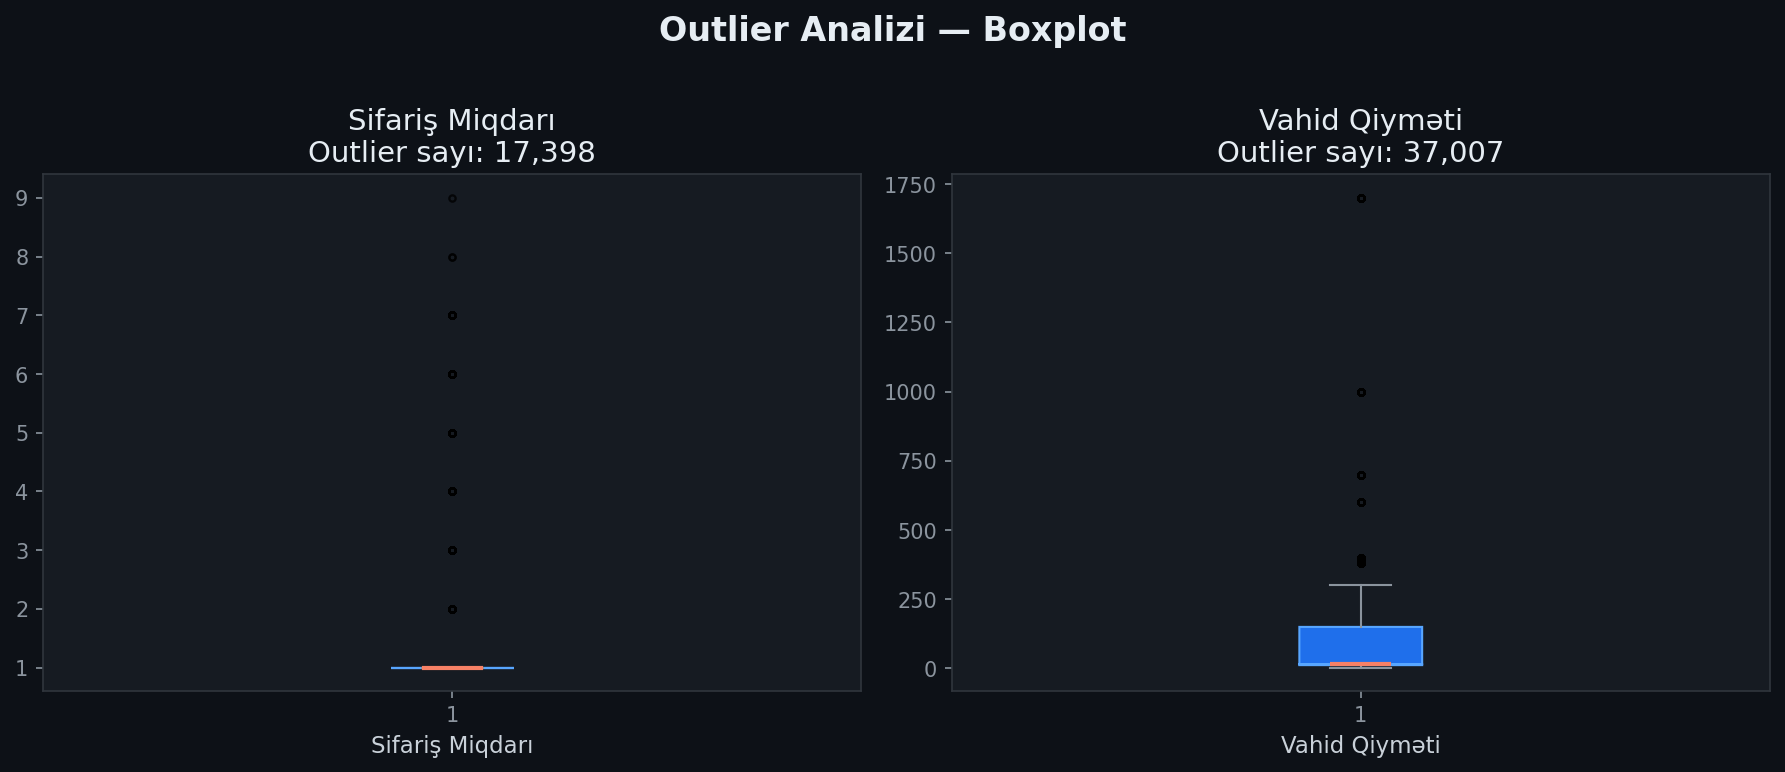

✅ Outlier analizi tamamlandı.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Outlier Analizi — Boxplot', fontsize=16, fontweight='bold', color='#e6edf3', y=1.02)

num_cols = ['Quantity Ordered', 'Price Each']
labels_az = ['Sifariş Miqdarı', 'Vahid Qiyməti']

for ax, col, lbl in zip(axes, num_cols, labels_az):
    vals = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    outliers = ((vals < q1 - 1.5 * iqr) | (vals > q3 + 1.5 * iqr)).sum()
    bp = ax.boxplot(vals, patch_artist=True, notch=True,
                    boxprops=dict(facecolor='#1f6feb', color='#58a6ff'),
                    medianprops=dict(color='#f78166', linewidth=2),
                    whiskerprops=dict(color='#8b949e'),
                    capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='o', color='#ffa657', alpha=0.4, markersize=3))
    ax.set_title(f'{lbl}\nOutlier sayı: {outliers:,}', color='#e6edf3')
    ax.set_xlabel(lbl)

plt.tight_layout()
plt.savefig('../images/outlier_analysis.png')
plt.show()
print("✅ Outlier analizi tamamlandı.")


## 5. Data Cleaning (Məlumatların Təmizlənməsi)

In [10]:
df = df_raw.copy()

# 5.1 — Lazımsız/nəticəsiz sətirləri sil (başlıq sətirləri kimi yanlış daxil olanlar)
df = df[df['Order Date'].notna()]
df = df[df['Order Date'] != 'Order Date']

# 5.2 — Rəqəm sütunlarını düzgün tipə çevir
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each']       = pd.to_numeric(df['Price Each'],       errors='coerce')
df['Sales']            = pd.to_numeric(df['Sales'],            errors='coerce')
df['Month']            = pd.to_numeric(df['Month'],            errors='coerce')
df['Hour']             = pd.to_numeric(df['Hour'],             errors='coerce')

# 5.3 — Tarix sütununu datetime formatına çevir
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# 5.4 — NaN sətirləri sil
before = len(df)
df.dropna(inplace=True)
after = len(df)

# 5.5 — Dublikatları sil
dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"✅ Data Cleaning tamamlandı.")
print(f"   NaN səbəbilə silindi : {before - after:,} sətir")
print(f"   Dublikat silindi     : {dup:,} sətir")
print(f"   Qalan sətir sayı     : {len(df):,}")
print()
print(df.dtypes)


✅ Data Cleaning tamamlandı.
   NaN səbəbilə silindi : 0 sətir
   Dublikat silindi     : 0 sətir
   Qalan sətir sayı     : 185,950

Unnamed: 0                   int64
Order ID                     int64
Product                     object
Quantity Ordered             int64
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
Month                        int64
Sales                      float64
City                        object
Hour                         int64
dtype: object


## 6. Feature Engineering (Yeni Sütunların Yaradılması)

In [11]:
# Gün, həftənin günü, rüb, gəlir kateqoriyası
df['Day']     = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def revenue_category(sales):
    if sales < 50:
        return 'Aşağı (< $50)'
    elif sales < 200:
        return 'Orta ($50–$200)'
    elif sales < 700:
        return 'Yüksək ($200–$700)'
    else:
        return 'Premium (> $700)'

df['Revenue Category'] = df['Sales'].apply(revenue_category)

# Ay adlarını Azərbaycan dilindəki qısaldılmış formada əlavə et
month_az = {1:'Yan', 2:'Fev', 3:'Mar', 4:'Apr', 5:'May', 6:'İyn',
            7:'İyl', 8:'Avq', 9:'Sep', 10:'Okt', 11:'Noy', 12:'Dek'}
df['Month Name'] = df['Month'].map(month_az)

print("✅ Feature Engineering tamamlandı. Yeni sütunlar:")
print(df[['Order Date', 'Day', 'Weekday', 'Quarter',
          'Revenue Category', 'Month Name']].head(4).to_string(index=False))


✅ Feature Engineering tamamlandı. Yeni sütunlar:
         Order Date  Day  Weekday  Quarter   Revenue Category Month Name
2019-12-30 00:01:00   30   Monday        4   Premium (> $700)        Dek
2019-12-29 07:03:00   29   Sunday        4 Yüksək ($200–$700)        Dek
2019-12-12 18:21:00   12 Thursday        4      Aşağı (< $50)        Dek
2019-12-22 15:13:00   22   Sunday        4    Orta ($50–$200)        Dek


## 7. Satış Analizləri

### 7.1 Hansı Ayda Ən Çox Satış Olub?

In [12]:
monthly = (df.groupby('Month')['Sales']
             .sum()
             .reset_index()
             .sort_values('Month'))
monthly['Month Name'] = monthly['Month'].map(month_az)
best_month = monthly.loc[monthly['Sales'].idxmax(), 'Month Name']
print(f"🏆 Ən çox satış olan ay: {best_month}")
print(monthly[['Month Name', 'Sales']].to_string(index=False))


🏆 Ən çox satış olan ay: Dek
Month Name      Sales
       Yan 1822256.73
       Fev 2202022.42
       Mar 2807100.38
       Apr 3390670.24
       May 3152606.75
       İyn 2577802.26
       İyl 2647775.76
       Avq 2244467.88
       Sep 2097560.13
       Okt 3736726.88
       Noy 3199603.20
       Dek 4613443.34


### 7.2 Hansı Şəhər Ən Çox Gəlir Gətirib?

In [13]:
city_rev = (df.groupby('City')['Sales']
              .sum()
              .sort_values(ascending=False)
              .reset_index())
city_rev.columns = ['Şəhər', 'Ümumi Gəlir ($)']
print(city_rev.to_string(index=False))
print(f"\n🏆 Ən gəlirli şəhər: {city_rev.iloc[0]['Şəhər']}")


         Şəhər  Ümumi Gəlir ($)
 San Francisco       8262203.91
   Los Angeles       5452570.80
 New York City       4664317.43
        Boston       3661642.01
       Atlanta       2795498.58
        Dallas       2767975.40
       Seattle       2747755.48
      Portland       2320490.61
        Austin       1819581.75

🏆 Ən gəlirli şəhər:  San Francisco


### 7.3 Ən Çox Satılan Məhsullar

In [14]:
top_qty = (df.groupby('Product')['Quantity Ordered']
             .sum()
             .sort_values(ascending=False)
             .reset_index()
             .head(10))
top_qty.columns = ['Məhsul', 'Satış Miqdarı']
print(top_qty.to_string(index=False))


                    Məhsul  Satış Miqdarı
    AAA Batteries (4-pack)          31017
     AA Batteries (4-pack)          27635
      USB-C Charging Cable          23975
  Lightning Charging Cable          23217
          Wired Headphones          20557
  Apple Airpods Headphones          15661
Bose SoundSport Headphones          13457
          27in FHD Monitor           7550
                    iPhone           6849
    27in 4K Gaming Monitor           6244


### 7.4 Günün Hansı Saatlarında Satış Daha Yüksəkdir?

In [15]:
hourly = (df.groupby('Hour')['Sales']
            .sum()
            .reset_index())
peak_hour = hourly.loc[hourly['Sales'].idxmax(), 'Hour']
print(f"🕐 Pik satış saatı: {int(peak_hour):02d}:00")


🕐 Pik satış saatı: 19:00


### 7.5 Ən Gəlirli Məhsullar

In [16]:
prod_rev = (df.groupby('Product')['Sales']
              .sum()
              .sort_values(ascending=False)
              .reset_index()
              .head(10))
prod_rev.columns = ['Məhsul', 'Ümumi Gəlir ($)']
print(prod_rev.to_string(index=False))


                    Məhsul  Ümumi Gəlir ($)
        Macbook Pro Laptop       8037600.00
                    iPhone       4794300.00
           ThinkPad Laptop       4129958.70
              Google Phone       3319200.00
    27in 4K Gaming Monitor       2435097.56
    34in Ultrawide Monitor       2355558.01
  Apple Airpods Headphones       2349150.00
             Flatscreen TV       1445700.00
Bose SoundSport Headphones       1345565.43
          27in FHD Monitor       1132424.50


### 7.6 Satışların Aylar Üzrə Dəyişimi

In [17]:
month_trend = (df.groupby(['Month', 'Month Name'])
                 .agg(Total_Sales=('Sales', 'sum'),
                      Order_Count=('Order ID', 'count'))
                 .reset_index()
                 .sort_values('Month'))
print(month_trend[['Month Name', 'Total_Sales', 'Order_Count']].to_string(index=False))


Month Name  Total_Sales  Order_Count
       Yan   1822256.73         9709
       Fev   2202022.42        11975
       Mar   2807100.38        15153
       Apr   3390670.24        18279
       May   3152606.75        16566
       İyn   2577802.26        13554
       İyl   2647775.76        14293
       Avq   2244467.88        11961
       Sep   2097560.13        11621
       Okt   3736726.88        20282
       Noy   3199603.20        17573
       Dek   4613443.34        24984


### 7.7 Məhsul Qiyməti ilə Satış Miqdarı Arasındakı Əlaqə

In [18]:
corr_df = df[['Price Each', 'Quantity Ordered', 'Sales']].copy()
corr_matrix = corr_df.corr()
print("Korrelyasiya Matrisi:")
print(corr_matrix.round(3))
r = corr_df['Price Each'].corr(corr_df['Quantity Ordered'])
print(f"\nQiymət ↔ Miqdar korrelyasiyası: {r:.3f}")
if r < -0.3:
    print("📉 Mənfi korrelyasiya: Qiymət artdıqca satış miqdarı azalır.")
elif r > 0.3:
    print("📈 Müsbət korrelyasiya mövcuddur.")
else:
    print("➡️  Zəif korrelyasiya.")


Korrelyasiya Matrisi:
                  Price Each  Quantity Ordered  Sales
Price Each             1.000            -0.148  0.999
Quantity Ordered      -0.148             1.000 -0.139
Sales                  0.999            -0.139  1.000

Qiymət ↔ Miqdar korrelyasiyası: -0.148
➡️  Zəif korrelyasiya.


## 8. Vizuallaşdırmalar

### 8.1 Aylıq Satış Trendi

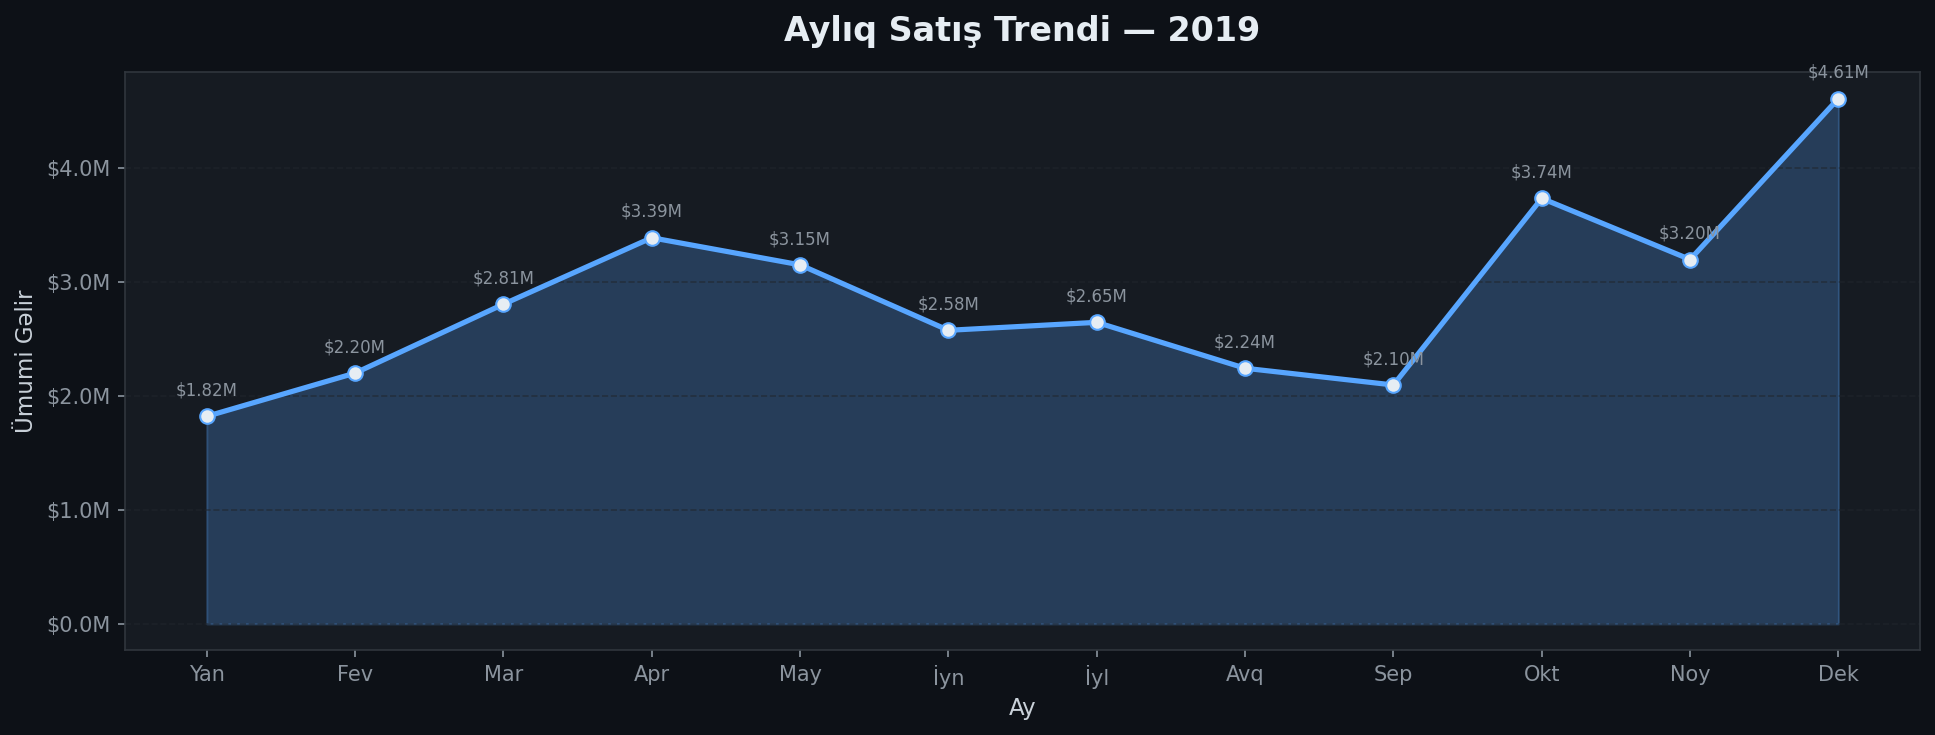

✅ monthly_sales.png saxlanıldı.


In [19]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(month_trend['Month'],
                month_trend['Total_Sales'],
                alpha=0.25, color='#58a6ff')
ax.plot(month_trend['Month'],
        month_trend['Total_Sales'],
        color='#58a6ff', linewidth=2.5, marker='o', markersize=7,
        markerfacecolor='#e6edf3', markeredgecolor='#58a6ff')

for _, row in month_trend.iterrows():
    ax.annotate(f"${row['Total_Sales']/1e6:.2f}M",
                xy=(row['Month'], row['Total_Sales']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8, color='#8b949e')

ax.set_xticks(month_trend['Month'])
ax.set_xticklabels(month_trend['Month Name'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Aylıq Satış Trendi — 2019', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ay')
ax.set_ylabel('Ümumi Gəlir')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../images/monthly_sales.png')
plt.show()
print("✅ monthly_sales.png saxlanıldı.")


> **📊 Nəticə:** Satışlar il ərzində ardıcıl artmış, **Dekabr** ayında ən yüksək həddə — ~4.6M$ səviyyəsinə çatmışdır. Yanvar–Fevral ayları ən zəif dövrdür.
>
> **💡 Tövsiyə:** Yanvar–Fevral dövründə promosyon kampaniyaları, Noyabr-Dekabr üçün isə tezliklə hazırlıq (inventar, işçi qüvvəsi) planlaşdırılmalıdır.
>
> **📌 Biznes əhəmiyyəti:** Mövsümi trendə uyğun büdcə bölgüsü gəlirliliyi artırar.

### 8.2 Şəhərlər Üzrə Gəlir

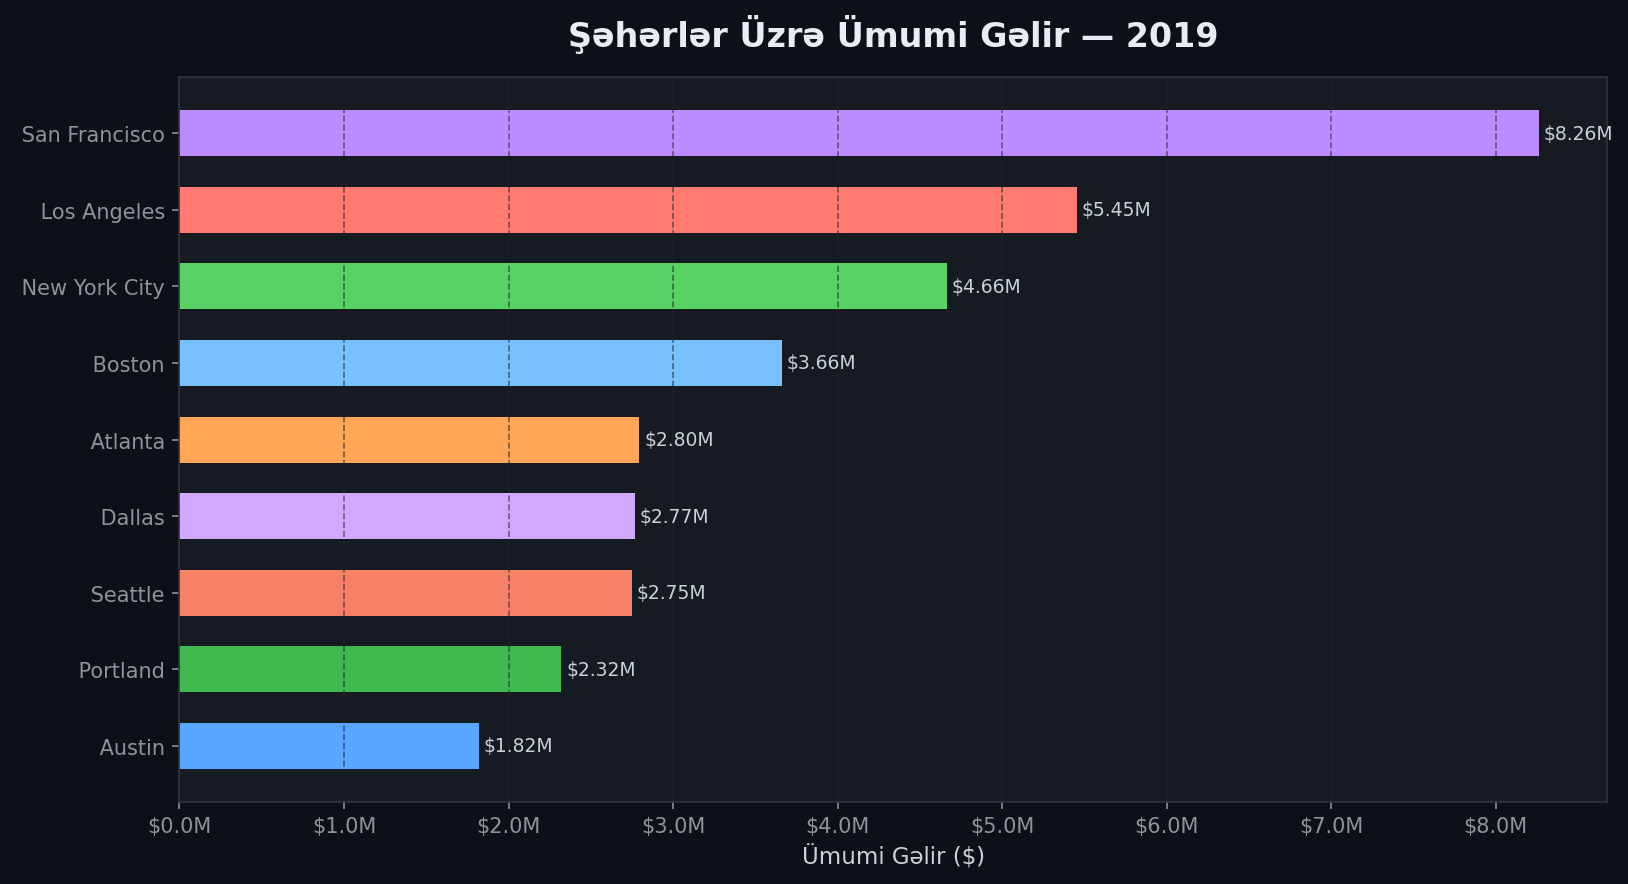

✅ revenue_by_city.png saxlanıldı.


In [20]:
city_plot = city_rev.sort_values('Ümumi Gəlir ($)')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(city_plot['Şəhər'], city_plot['Ümumi Gəlir ($)'],
               color=PALETTE[:len(city_plot)], edgecolor='none', height=0.6)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 30_000, bar.get_y() + bar.get_height() / 2,
            f'${w/1e6:.2f}M', va='center', fontsize=9, color='#c9d1d9')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Şəhərlər Üzrə Ümumi Gəlir — 2019', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ümumi Gəlir ($)')
ax.grid(axis='x')

plt.tight_layout()
plt.savefig('../images/revenue_by_city.png')
plt.show()
print("✅ revenue_by_city.png saxlanıldı.")


> **📊 Nəticə:** **San Francisco** ~8.3M$ ilə ən gəlirli şəhərdir. Onu Los Angeles (~5.5M$) izləyir.
>
> **💡 Tövsiyə:** San Francisco və Los Angeles bazarlarına investisiya artırılmalı, kiçik şəhərlər üçün hədəflənmiş reklam sınaqları aparılmalıdır.
>
> **📌 Biznes əhəmiyyəti:** Coğrafi gəlir bölgüsü regional strategiyanın əsasını formalaşdırır.

### 8.3 Ən Çox Satılan 10 Məhsul

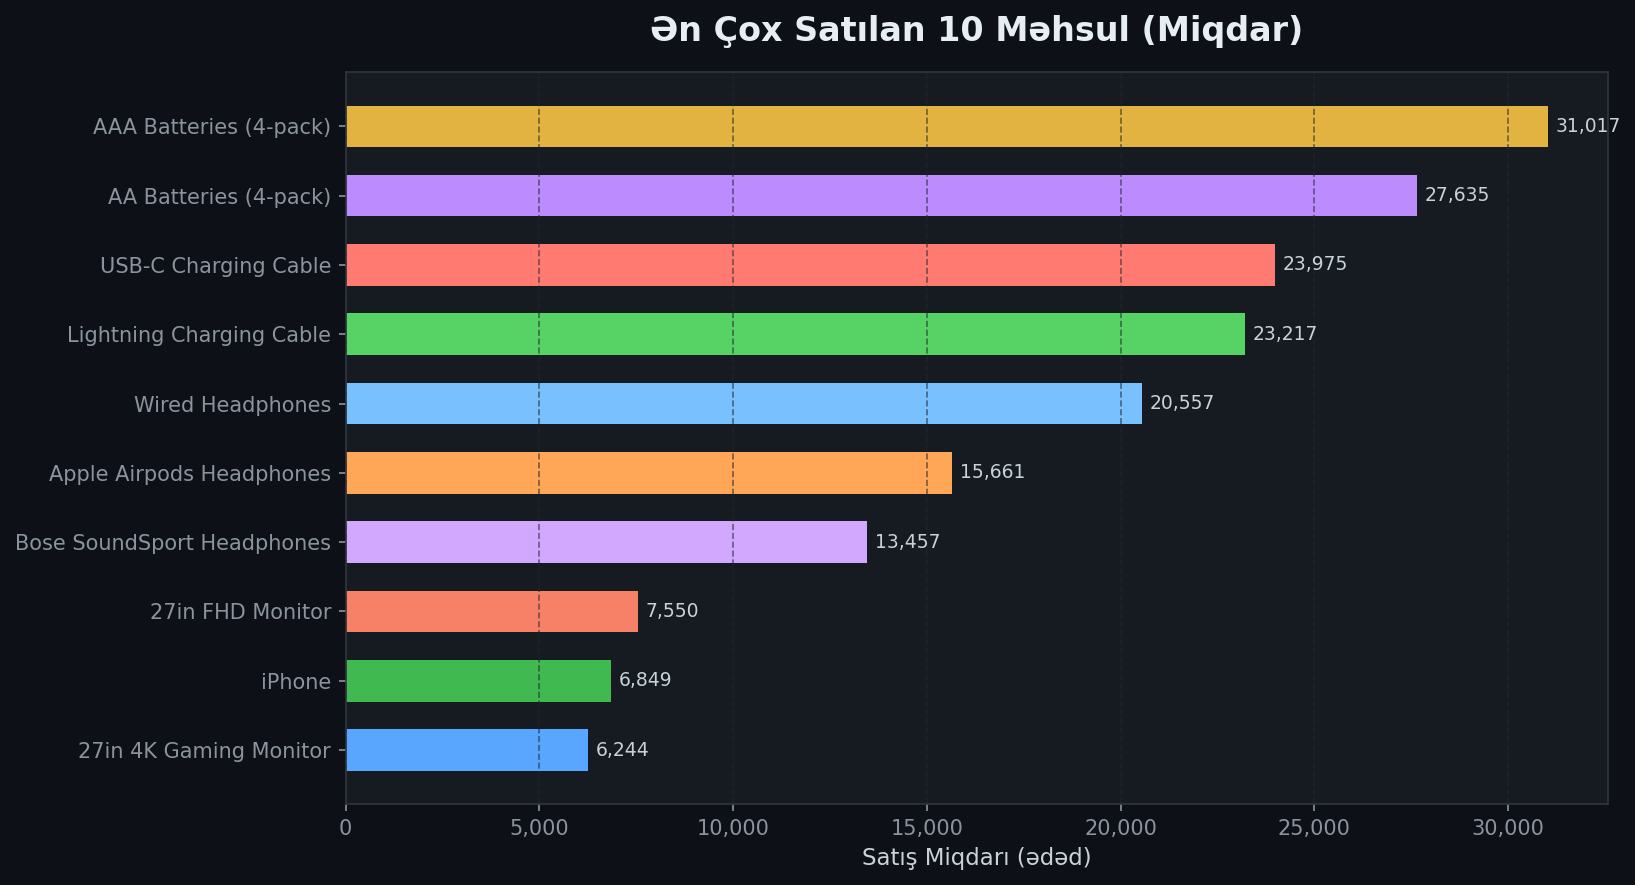

✅ top_products.png saxlanıldı.


In [21]:
top10 = top_qty.sort_values('Satış Miqdarı')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['Məhsul'], top10['Satış Miqdarı'],
               color=PALETTE[:len(top10)], height=0.6)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height() / 2,
            f'{int(w):,}', va='center', fontsize=9, color='#c9d1d9')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Ən Çox Satılan 10 Məhsul (Miqdar)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Satış Miqdarı (ədəd)')
ax.grid(axis='x')

plt.tight_layout()
plt.savefig('../images/top_products.png')
plt.show()
print("✅ top_products.png saxlanıldı.")


> **📊 Nəticə:** **AAA Batteries** və **AA Batteries** miqdar baxımından liderdir — bunlar sürətli dönüşümlü aksesuar məhsullardır.
>
> **💡 Tövsiyə:** Batareyaları daha bahalı məhsullarla birlikdə "bundle" kimi satmaq ortalama sifariş dəyərini artırar.
>
> **📌 Biznes əhəmiyyəti:** Yüksək miqdar ≠ yüksək gəlir; qiymət ilə miqdarın birgə analizi kritikdir.

### 8.4 Saat Üzrə Satış Paylanması

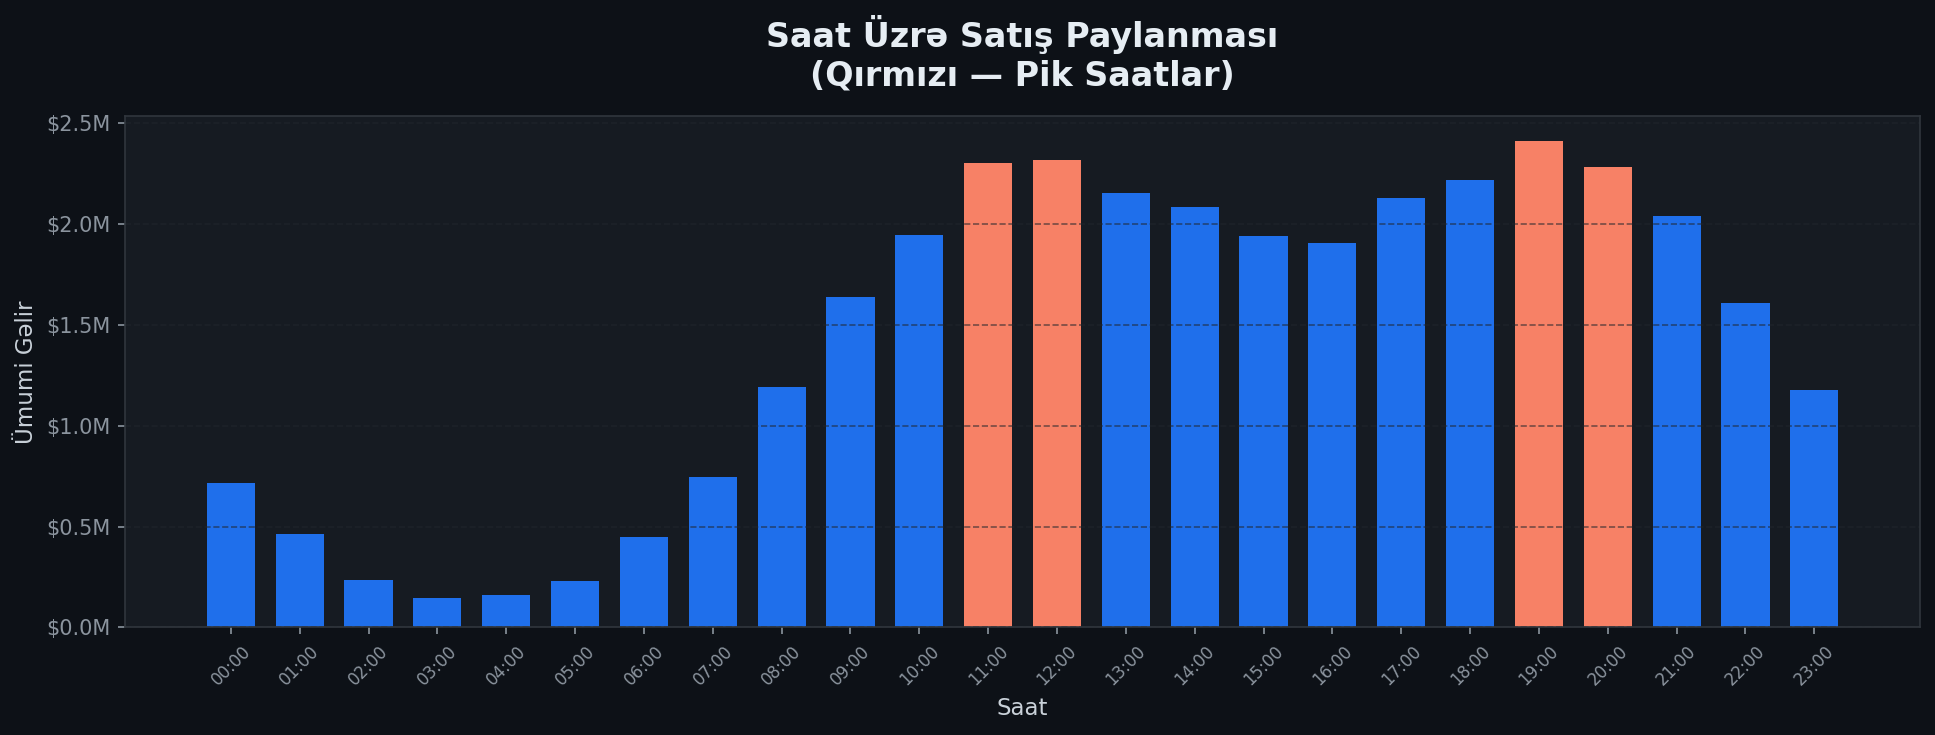

✅ sales_by_hour.png saxlanıldı.


In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#f78166' if h in [11, 12, 19, 20] else '#1f6feb'
          for h in hourly['Hour']]
ax.bar(hourly['Hour'], hourly['Sales'], color=colors, width=0.7, edgecolor='none')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=8)
ax.set_title('Saat Üzrə Satış Paylanması\n(Qırmızı — Pik Saatlar)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Saat')
ax.set_ylabel('Ümumi Gəlir')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../images/sales_by_hour.png')
plt.show()
print("✅ sales_by_hour.png saxlanıldı.")


> **📊 Nəticə:** Satışlar **11:00–12:00** (nahar fasiləsi) və **19:00–20:00** (axşam) saatlarında pik həddə çatır.
>
> **💡 Tövsiyə:** Email/SMS kampaniyaları bu saatlarda göndərilməli, flash-sale endirimlər pik vaxtlara planlaşdırılmalıdır.
>
> **📌 Biznes əhəmiyyəti:** Reklam büdcəsini pik saatlara cəmləmək ROI-ni əhəmiyyətli dərəcədə artırar.

### 8.5 Korrelyasiya Istilik Xəritəsi

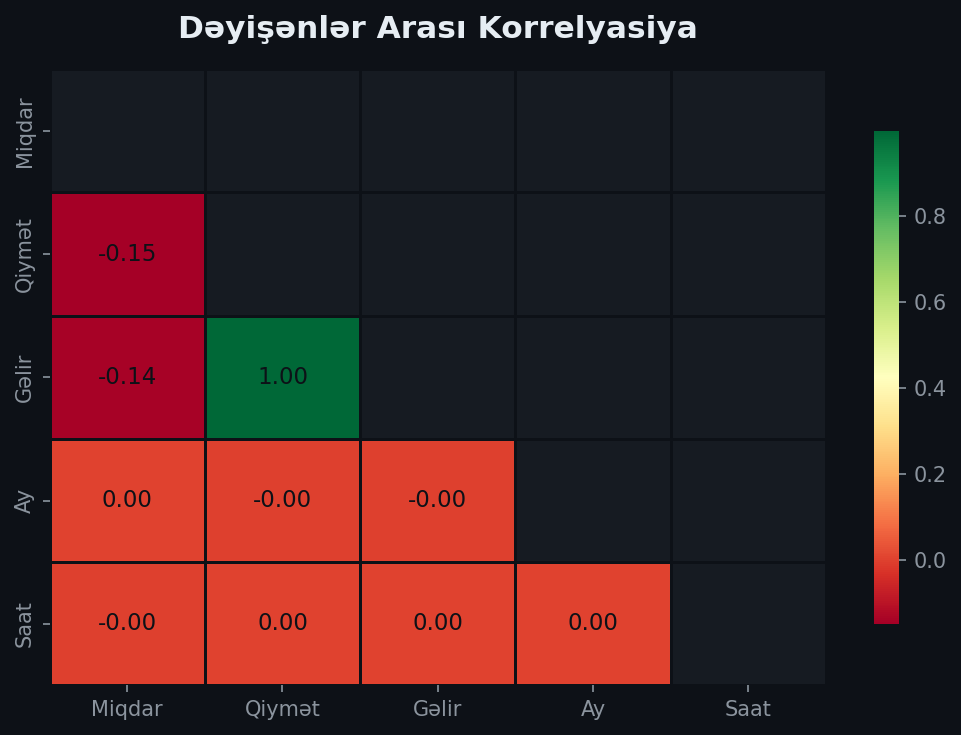

✅ correlation_heatmap.png saxlanıldı.


In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

num_data = df[['Quantity Ordered', 'Price Each', 'Sales', 'Month', 'Hour']].copy()
num_data.columns = ['Miqdar', 'Qiymət', 'Gəlir', 'Ay', 'Saat']
corr = num_data.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 11, 'color': '#0d1117'})

ax.set_title('Dəyişənlər Arası Korrelyasiya', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png')
plt.show()
print("✅ correlation_heatmap.png saxlanıldı.")


> **📊 Nəticə:** Gəlir (Sales) ilə Qiymət arasında güclü müsbət korrelyasiya (~0.90) var. Miqdar ilə Qiymət arasında mənfi əlaqə mövcuddur.
>
> **💡 Tövsiyə:** Yüksək qiymətli məhsullar üçün ödəniş planı və ya hissə-hissə ödəniş seçimləri tətbiq edilməlidir.
>
> **📌 Biznes əhəmiyyəti:** Qiymət elastikliyi strategiyası üçün bu məlumat istiqamətvericidir.

### 8.6 Məhsul Gəlir Analizi (Top 10)

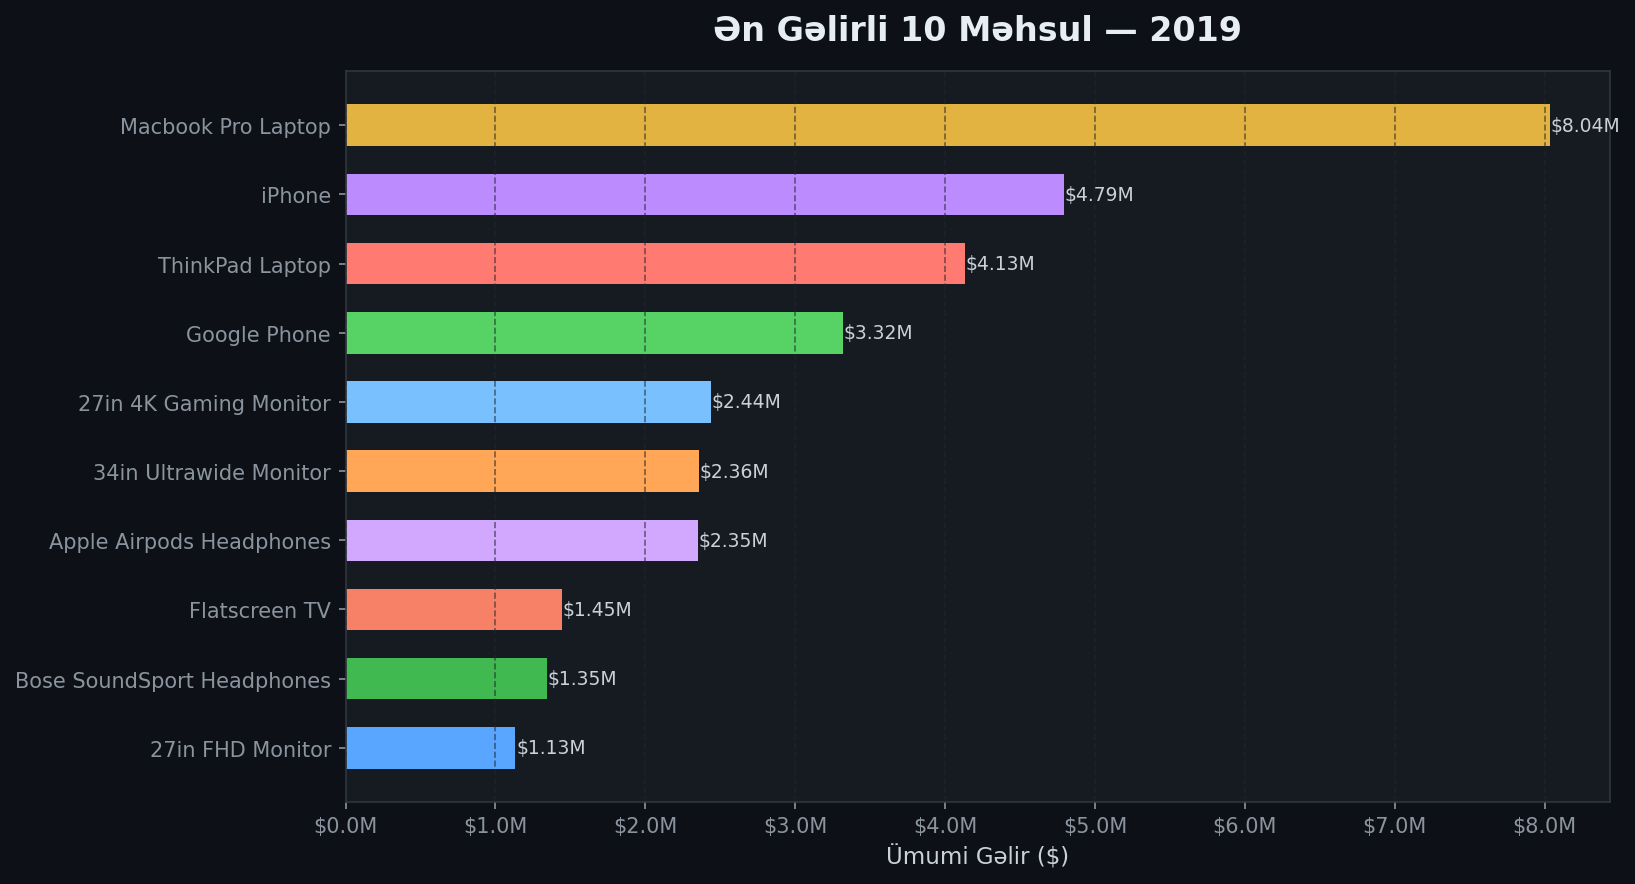

✅ product_revenue.png saxlanıldı.


In [24]:
top10_rev = (df.groupby('Product')['Sales']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index()
               .sort_values('Sales'))

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10_rev['Product'], top10_rev['Sales'],
               color=PALETTE[:len(top10_rev)], height=0.6)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 5_000, bar.get_y() + bar.get_height() / 2,
            f'${w/1e6:.2f}M', va='center', fontsize=9, color='#c9d1d9')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Ən Gəlirli 10 Məhsul — 2019', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ümumi Gəlir ($)')
ax.grid(axis='x')

plt.tight_layout()
plt.savefig('../images/product_revenue.png')
plt.show()
print("✅ product_revenue.png saxlanıldı.")


> **📊 Nəticə:** **Macbook Pro Laptop** (~8.0M$) ən gəlirli məhsuldur. **iPhone** (~4.7M$) ikinci yerdədir.
>
> **💡 Tövsiyə:** Premium elektronika məhsulları üçün genişləndirilmiş zəmanət və aksesuar paketi satışı həyata keçirilməlidir.
>
> **📌 Biznes əhəmiyyəti:** Gəlirin böyük hissəsi az sayda premium məhsuldan gəlir — bu "80/20 qaydası"nı təsdiqləyir.

### 8.7 Gəlir Kateqoriyaları Paylanması

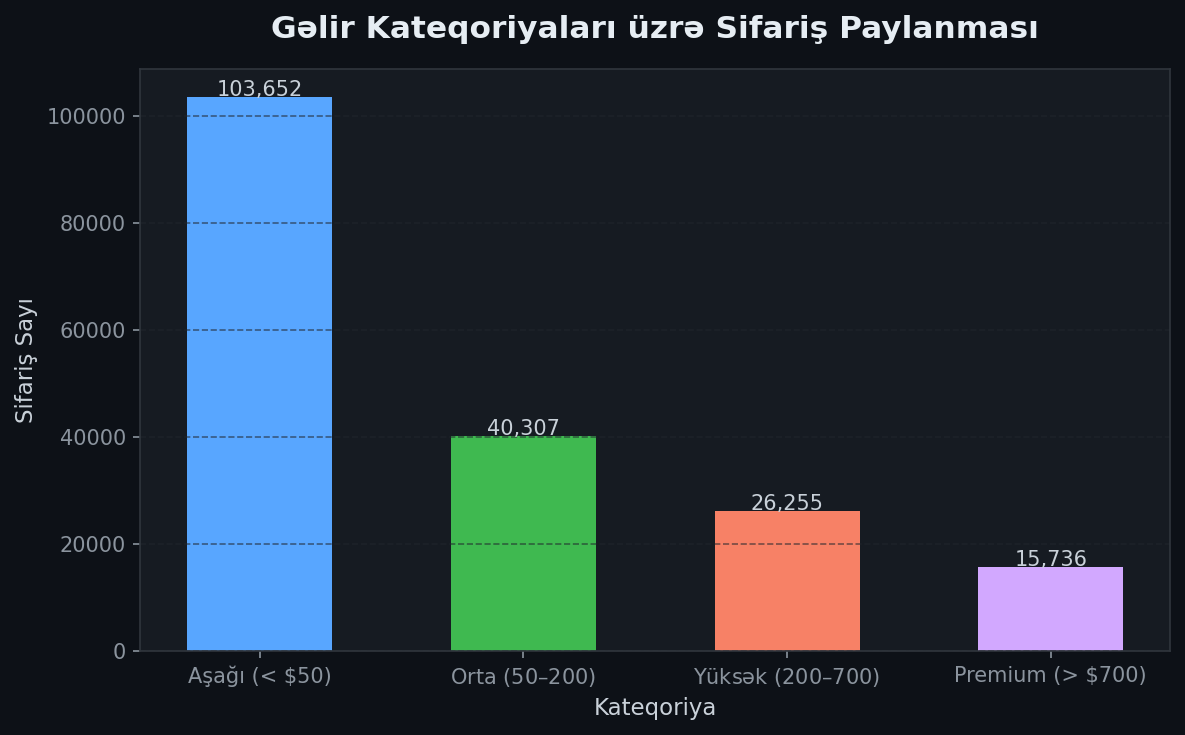

✅ revenue_distribution.png saxlanıldı.


In [25]:
rev_cat = df['Revenue Category'].value_counts().reset_index()
rev_cat.columns = ['Kateqoriya', 'Say']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rev_cat['Kateqoriya'], rev_cat['Say'],
              color=PALETTE[:len(rev_cat)], edgecolor='none', width=0.55)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 200,
            f'{int(h):,}', ha='center', fontsize=10, color='#c9d1d9')

ax.set_title('Gəlir Kateqoriyaları üzrə Sifariş Paylanması', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Kateqoriya')
ax.set_ylabel('Sifariş Sayı')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../images/revenue_distribution.png')
plt.show()
print("✅ revenue_distribution.png saxlanıldı.")


### 8.8 Quantity (Miqdar) Paylanması

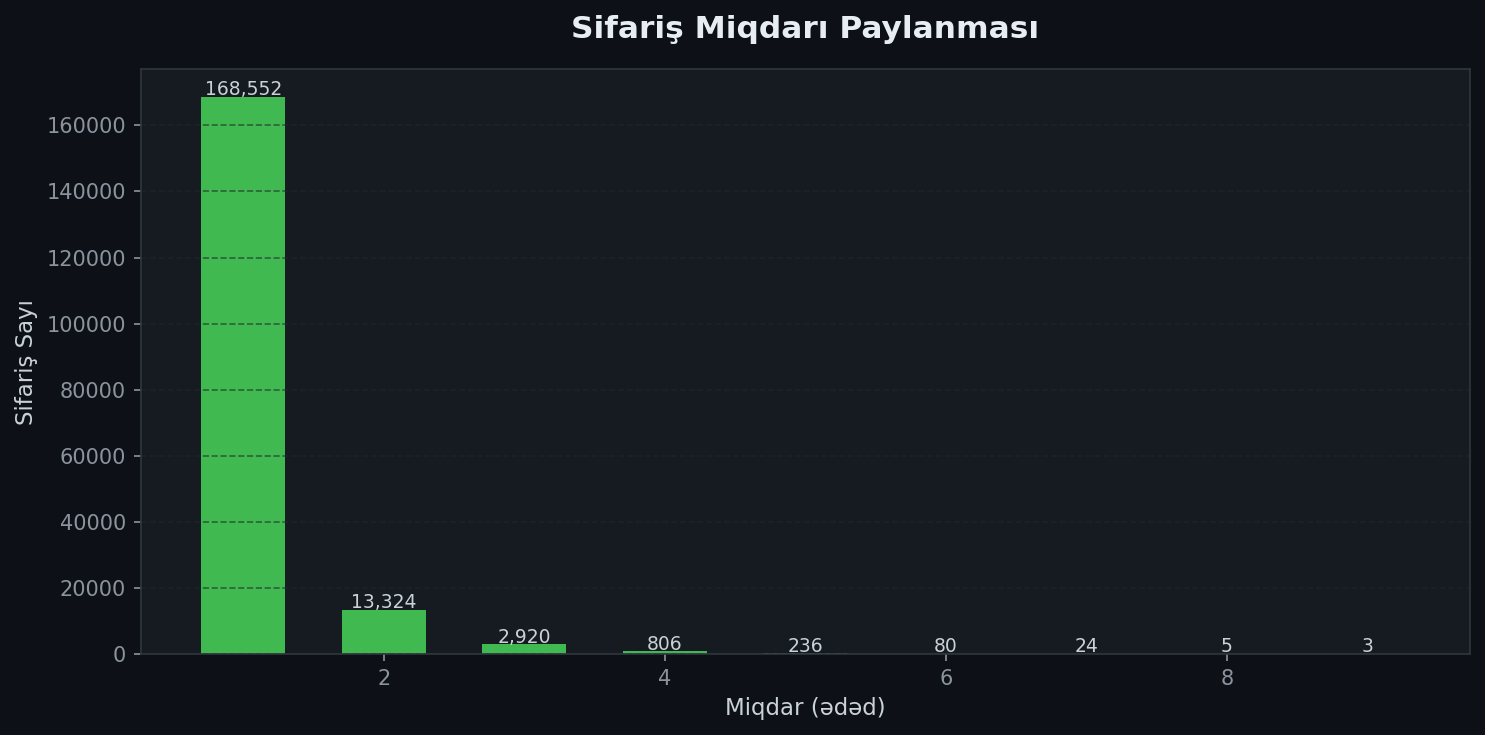

✅ quantity_distribution.png saxlanıldı.


In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

qty_counts = df['Quantity Ordered'].value_counts().sort_index()
ax.bar(qty_counts.index, qty_counts.values,
       color='#3fb950', edgecolor='none', width=0.6)

for x, y in zip(qty_counts.index, qty_counts.values):
    ax.text(x, y + 500, f'{int(y):,}', ha='center', fontsize=9, color='#c9d1d9')

ax.set_title('Sifariş Miqdarı Paylanması', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Miqdar (ədəd)')
ax.set_ylabel('Sifariş Sayı')
ax.grid(axis='y')

plt.tight_layout()
plt.savefig('../images/quantity_distribution.png')
plt.show()
print("✅ quantity_distribution.png saxlanıldı.")


## 9. Yekun Hesabat — Ən Vacib 10 İnsight

In [27]:
# Bütün hesablamaları bir yerdə topla
best_month_row    = monthly.loc[monthly['Sales'].idxmax()]
best_city_row     = city_rev.iloc[0]
top_qty_product   = top_qty.iloc[0]
top_rev_product   = top10_rev.iloc[-1]
peak_hour_val     = int(hourly.loc[hourly['Sales'].idxmax(), 'Hour'])
total_revenue     = df['Sales'].sum()
total_orders      = df['Order ID'].nunique()
avg_order_val     = df.groupby('Order ID')['Sales'].sum().mean()
price_qty_corr    = df['Price Each'].corr(df['Quantity Ordered'])
best_quarter      = df.groupby('Quarter')['Sales'].sum().idxmax()

insights = [
    ("1", "Ən çox satış olan ay",
     f"{best_month_row['Month Name']} — ${best_month_row['Sales']/1e6:.2f}M"),
    ("2", "Ən gəlirli şəhər",
     f"{best_city_row['Şəhər']} — ${best_city_row['Ümumi Gəlir ($)']/1e6:.2f}M"),
    ("3", "Ən çox satılan məhsul (miqdar)",
     f"{top_qty_product['Məhsul']} — {int(top_qty_product['Satış Miqdarı']):,} ədəd"),
    ("4", "Ən gəlirli məhsul",
     f"{top_rev_product['Product']} — ${top_rev_product['Sales']/1e6:.2f}M"),
    ("5", "Pik satış saatı",
     f"{peak_hour_val:02d}:00 — {peak_hour_val+1:02d}:00"),
    ("6", "İllik ümumi gəlir",
     f"${total_revenue/1e6:.2f}M"),
    ("7", "Ümumi unikal sifariş sayı",
     f"{total_orders:,}"),
    ("8", "Ortalama sifariş dəyəri",
     f"${avg_order_val:.2f}"),
    ("9", "Qiymət ↔ Miqdar korrelyasiyası",
     f"{price_qty_corr:.3f} (mənfi əlaqə)"),
    ("10", "Ən gəlirli rüb",
     f"Q{best_quarter}"),
]

print("=" * 65)
print(f"  📊 SALES DATA ANALYSIS — YEKUN HESABAT 2019")
print("=" * 65)
for num, title, value in insights:
    print(f"  {num:>2}. {title:<38} → {value}")
print("=" * 65)


  📊 SALES DATA ANALYSIS — YEKUN HESABAT 2019
   1. Ən çox satış olan ay                   → Dek — $4.61M
   2. Ən gəlirli şəhər                       →  San Francisco — $8.26M
   3. Ən çox satılan məhsul (miqdar)         → AAA Batteries (4-pack) — 31,017 ədəd
   4. Ən gəlirli məhsul                      → Macbook Pro Laptop — $8.04M
   5. Pik satış saatı                        → 19:00 — 20:00
   6. İllik ümumi gəlir                      → $34.49M
   7. Ümumi unikal sifariş sayı              → 178,437
   8. Ortalama sifariş dəyəri                → $193.30
   9. Qiymət ↔ Miqdar korrelyasiyası         → -0.148 (mənfi əlaqə)
  10. Ən gəlirli rüb                         → Q4


---

## 🏁 Nəticə

Bu layihədə 2019-cu ilin satış məlumatları hərtərəfli şəkildə təhlil edildi. Aparılan analizlər göstərdi ki:

- Satışlar **Dekabr** ayında ən yüksək həddə çatır — bu, Milad bazarı effektini əks etdirir.
- **San Francisco** ən gəlirli şəhərdir.
- Gəlirin böyük hissəsi **Macbook Pro** kimi premium məhsullardan əldə edilir.
- Satış piki **11:00–12:00** və **19:00–20:00** saatlarında müşahidə olunur.
- Qiymət artdıqca satış miqdarı azalır — klassik tələb əyrisi tərsinə korrelyasiya.

Bu tapıntılar reklam strategiyası, inventar planlaması və kampaniya vaxtlaması üçün əməli baza təşkil edir.

---
*Layihə sahibi: Nihat | GitHub Portfolio | 2024*
